In [1]:
import tensorflow 

In [2]:
import cv2 as cv 
img=cv.imread("C:\\Users\\akhil\\OneDrive\\Documents\\birthday pic.jpg") 
cv.imread('Cat',img) 
cv.waitKey(0) # waits indefinitely for a key press before continuing program execution. 

-1

In [5]:
import cv2 as cv 
img = cv.imread("C:\\Users\\akhil\\OneDrive\\Documents\\birthday pic.jpg") 

print("shape :",img.shape) # returns a tuple of no.of rows, columns, and channels.
print("size: ",img.size)  # returns total no fo pixels used
print("type: ",img.dtype)  # returns image datatype is obtained
b,g,r = cv.split(img)

img = cv.merge((b,g,r))    # ROI - Region  of Intrest

cv.imshow('image',img)
cv.waitKey(0)

shape : (4080, 3060, 3)
size:  37454400
type:  uint8


-1

In [8]:
import numpy as np
import cv2

# Read first image from given path
img = cv2.imread("C:\\Users\\akhil\\OneDrive\\Pictures\\Screenshots\\Screenshot 2025-12-07 192924.png")

# Read second image from given path
img2 = cv2.imread("C:\\Users\\akhil\\OneDrive\\Pictures\\Screenshots\\Screenshot 2025-03-09 094841.png")

# Split the image into Blue, Green, Red channels
b, g, r = cv2.split(img)

# Resize both images to same size (important for merging)
img = cv2.resize(img, (512, 512))     # why 512 means , pixels values ranges from 0 to 511
img2 = cv2.resize(img2, (512, 512))


# This adds pixel values of both images directly ,If value exceeds 255, OpenCV automatically caps it at 255
dst = cv2.add(img, img2)


#merges the both the images , image with more weight appears fully
dst2 = cv2.addWeighted(img, 0.8, img2, 0.2, 0) # 0.8 and 0.2 are the weights of the img1 and img2 , image with more weight appears fully


cv2.imshow('Simple Add', dst)

cv2.imshow('Weighted Blend', dst2)

cv2.waitKey(0)

cv2.destroyAllWindows()

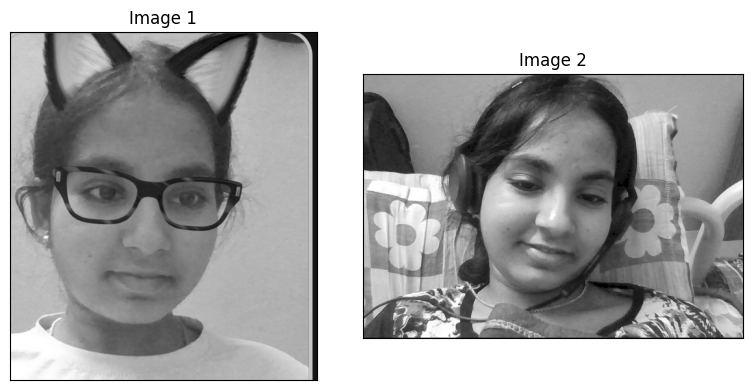

In [4]:
import cv2
from matplotlib import pyplot as plt 

# Load images 
img1 = cv2.imread("C:\\Users\\akhil\\OneDrive\\Pictures\\Screenshots\\Screenshot 2026-02-14 214223.png", 0)   # 0 = grayscale
img2 = cv2.imread("C:\\Users\\akhil\\OneDrive\\Pictures\\Screenshots\\Screenshot 2025-12-10 211029.png", 0)

images = [img1, img2]
titles = ["Image 1", "Image 2"]

plt.figure(figsize=(8, 4))

for i in range(2):
    plt.subplot(1, 2, i + 1) # 1- row , 2 - columns , i+1 means iteration
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]) # This removes the x-axis plot numbers 
    plt.yticks([]) # This removes the y-axis plot numbers 

plt.tight_layout()
plt.show()

In [ ]:
morphological transformations are generally performed on binary images , these are the transformations on the image shape

### Track Bars

In [7]:
import cv2 as cv
import numpy as np


img = np.zeros((300, 512, 3), np.uint8) 

cv.namedWindow('image')  # Create a window with name 'image'

# ---------------------------------------
# Dummy function (Trackbar requires it)
# ---------------------------------------
def nothing(x):
    pass


# ---------------------------------------
# Create Trackbars for B, G, R colors
# ---------------------------------------
cv.createTrackbar('B', 'image', 0, 255, nothing)
cv.createTrackbar('G', 'image', 0, 255, nothing)
cv.createTrackbar('R', 'image', 0, 255, nothing)


# ---------------------------------------
# Create ON/OFF switch trackbar
# ---------------------------------------
switch = '0 : OFF \n1 : ON'
cv.createTrackbar(switch, 'image', 0, 1, nothing)


# ---------------------------------------
# Infinite loop to update image in real-time
# ---------------------------------------
while True:
    cv.imshow('image', img)

    # Wait 1 ms and check if ESC is pressed
    k = cv.waitKey(1) & 0xFF
    if k == 27:   # ESC key ASCII = 27      , use only esc button to close , otherwise u will get error
        break

    # Get current positions of trackbars
    b = cv.getTrackbarPos('B', 'image')
    g = cv.getTrackbarPos('G', 'image')
    r = cv.getTrackbarPos('R', 'image')
    s = cv.getTrackbarPos(switch, 'image')

    # If switch is OFF
    if s == 0:
        img[:] = 0   # Make image black
    else:
        img[:] = [b, g, r]   # Apply selected BGR color

# Close window
cv.destroyAllWindows() 

In [1]:
import cv2 as cv 
import numpy as np 


def nothing(x):
    pass


cap = cv.VideoCapture(0) 


if not cap.isOpened(): 
    print("Camera not opened") 
    exit() 


cv.namedWindow("Tracking") 


# Lower HSV 
cv.createTrackbar("LH", "Tracking", 0, 255, nothing) 
cv.createTrackbar("LS", "Tracking", 0, 255, nothing) 
cv.createTrackbar("LV", "Tracking", 0, 255, nothing) 


# Upper HSV
cv.createTrackbar("UH", "Tracking", 255, 255, nothing) 
cv.createTrackbar("US", "Tracking", 255, 255, nothing)   
cv.createTrackbar("UV", "Tracking", 255, 255, nothing) 


while True: 
    ret, frame = cap.read() 
    if not ret:
        break 

    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV) 

    # Get trackbar values
    l_h = cv.getTrackbarPos("LH", "Tracking") 
    l_s = cv.getTrackbarPos("LS", "Tracking") 
    l_v = cv.getTrackbarPos("LV", "Tracking") 

    u_h = cv.getTrackbarPos("UH", "Tracking") 
    u_s = cv.getTrackbarPos("US", "Tracking") 
    u_v = cv.getTrackbarPos("UV", "Tracking") 

    lower = np.array([l_h, l_s, l_v]) 
    upper = np.array([u_h, u_s, u_v]) 

    # Create mask 
    mask = cv.inRange(hsv, lower, upper) 

    # Apply mask
    res = cv.bitwise_and(frame, frame, mask=mask ) 

    cv.imshow("Frame", frame)   
    cv.imshow("Mask", mask) 
    cv.imshow("Result", res)   

    if cv.waitKey(1) & 0xFF == 27:
        break 

cap.release() 
cv.destroyAllWindows() 


In [ ]:
import numpy as np
import cv2 as cv

frame = cv.imread("C:\\Users\\akhil\\OneDrive\\Pictures\\Screenshots\\Screenshot 2025-12-07 192924.png")

if frame is None:
    print("Image not found!")
    exit()

hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)

l_b = np.array([110, 50, 50]) 
u_b = np.array([130, 255, 255]) 

mask = cv.inRange(hsv, l_b, u_b)
res = cv.bitwise_and(frame, frame, mask=mask)

cv.imshow("Frame", frame)
cv.imshow("Mask", mask)
cv.imshow("Result", res)

cv.waitKey(0)
cv.destroyAllWindows()


### Bitwise Operations

In [ ]:
import cv2
import numpy as np

# ---------------------------------------
# Create First Blank Image (Black)
# ---------------------------------------
img1 = np.zeros((400, 600, 3), np.uint8)

# Draw White Rectangle on img1
cv2.rectangle(img1, (50, 50), (250, 250), (255, 255, 255), -1)

# ---------------------------------------
# Create Second Blank Image (Black)
# ---------------------------------------
img2 = np.zeros((400, 600, 3), np.uint8)

# Draw White Rectangle on img2 (Different position)
cv2.rectangle(img2, (150, 150), (350, 350), (255, 255, 255), -1)

# ---------------------------------------
# Apply Bitwise Operations
# ---------------------------------------
bitAnd = cv2.bitwise_and(img1, img2)
bitOr  = cv2.bitwise_or(img1, img2)
bitXor = cv2.bitwise_xor(img1, img2)
bitNot1 = cv2.bitwise_not(img1)
bitNot2 = cv2.bitwise_not(img2)

# ---------------------------------------
# Show Results
# ---------------------------------------
cv2.imshow("Image 1", img1)
cv2.imshow("Image 2", img2)
cv2.imshow("Bitwise AND", bitAnd)
cv2.imshow("Bitwise OR", bitOr)
cv2.imshow("Bitwise XOR", bitXor)
cv2.imshow("Bitwise NOT - Image1", bitNot1)
cv2.imshow("Bitwise NOT - Image2", bitNot2)

cv2.waitKey(0)
cv2.destroyAllWindows()


### Video Capture 

In [5]:
    
import cv2

cap = cv2.VideoCapture(0); # in the place of zero , we can pass our own video file

print(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) # prints the width of the frame
print(cap.get(cv2.CAP_PROP_FRAME_Height)
      

while(cap.isOpened()):   # if video/camera is opened, then only it captures the frame
    ret,frame=cap.read()

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # converted the frame to gray color
    cv2.imshow('frame',gray)

    if cv2.waitKey(0):   # in the place of '0' , we can also pass the 5000 means the frame is visible for 5 seconds and then closed automatically
        break
        
cap.release()
cv2.destroyAllWindows()

In [3]:
import cv2 as cv 

img = cv.imread(r"C:\Users\akhil\OneDrive\Documents\birthday pic.jpg") 
cv.imshow('Birthday Pic', img) 
cv.waitKey(0) 

-1

In [2]:
import cv2

img = cv2.imread("C:\\Users\\akhil\\OneDrive\\Pictures\\Screenshots\\Screenshot 2025-12-10 183100.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

equalized = cv2.equalizeHist(gray)

cv2.imshow("Original", gray)
cv2.imshow("Equalized", equalized)

cv2.waitKey(0)
cv2.destroyAllWindows()

### Resizing and Rescaling

In [4]:
import cv2 as cv                

img = cv.imread(r"C:\Users\akhil\OneDrive\Documents\birthday pic.jpg") 
#cv.imshow('Birthday Pic', img) 
def rescaleFrame(frame,scale=0.35):    # 0.35 means the new image will be 35% of the original size in both width and height.
    width=int(frame.shape[1] * scale) 
    height=int(frame.shape[0] * scale) 

    dimensions = (width , height) 
    return cv.resize(frame,dimensions,interpolation=cv.INTER_AREA)  # INTER_AREA is best for shrinking image
resized_img = rescaleFrame(img) 

# Display original and resized images 
#cv.imshow('Original Image', img) 
cv.imshow('Resized Image', resized_img) 

#change width and height will work only for the live videos like webcam 

cv.waitKey(0) 
cv.destroyAllWindows() 
cv.waitKey(0) 

-1

### Different types of Shapes, Text feild, Line, Date

In [ ]:
import cv2 as cv 
import numpy as np 

# Create a blank image 
blank = np.zeros((500, 500, 3), dtype='uint8') 


# Color the entire image red 
blank[:] = 0, 0, 255 
cv.imshow('Full Red', blank) 


# Color a small region (green rectangle area) 
blank[200:300, 300:400] = 0, 255, 0 
cv.imshow('Partial Green', blank) 


# Draw a rectangle outline (blue) 
cv.rectangle(blank, (0, 0), (250, 250), (255, 0, 0), thickness=2) 
cv.imshow('Rectangle', blank) 


cv.circle(blank, (250, 250), 100, (0, 255, 0), thickness=3)  # green circle outline 
cv.imshow('Circle', blank) 


# Draw a line 
# Syntax: cv.line(image, start_point, end_point, color, thickness) 
cv.line(blank, (0, 0), (500, 500), (255, 0, 0), thickness=2)  # blue diagonal line 
cv.imshow('Line', blank)  


# write text 
font = cv.FONT_HERSHEY_SIMPLEX 
cv.putText(blank,'Hello',(0,255),font, 1.0, (0,255,0), thickness=2)  # in this '1.0' represents the font size 
cv.imshow('Text', blank) 

dater = str(datetime.datetime.now())  #print date
cv.putText(blank, date, (0,255), font, 1.0, (0,255,0), thickness=2)  # in this '1.0' represents the font size 
cv.imshow('Text', blank) 

cv.waitKey(0) 
cv.destroyAllWindows() 


### Events

In [1]:
import cv2 as cv 

events = [i for i in dir(cv) if 'EVENT' in i]
print(events) 

['EVENT_FLAG_ALTKEY', 'EVENT_FLAG_CTRLKEY', 'EVENT_FLAG_LBUTTON', 'EVENT_FLAG_MBUTTON', 'EVENT_FLAG_RBUTTON', 'EVENT_FLAG_SHIFTKEY', 'EVENT_LBUTTONDBLCLK', 'EVENT_LBUTTONDOWN', 'EVENT_LBUTTONUP', 'EVENT_MBUTTONDBLCLK', 'EVENT_MBUTTONDOWN', 'EVENT_MBUTTONUP', 'EVENT_MOUSEHWHEEL', 'EVENT_MOUSEMOVE', 'EVENT_MOUSEWHEEL', 'EVENT_RBUTTONDBLCLK', 'EVENT_RBUTTONDOWN', 'EVENT_RBUTTONUP']


### Mouse Events ( Right Click, Left Click)

In [2]:
import cv2 as cv
import numpy as np

def click_event(event , x,y,flas,param):
    if event == cv.EVENT_LBUTTONDOWN:     # for the left click
        print(x,',',y)
        font = cv.FONT_HERSHEY_SIMPLEX 
        strxy = str(x) + ',' + str(y)
        cv.putText(blank,'Hello',(0,255),font, 1.0, (0,255,0), thickness=2)  
 # in this whenever we left click in the frame ,the text ' hello' appears
        cv.imshow('Text', blank) 

    
    if event == cv.EVENT_RBUTTONDOWN:   # for the right click
        blue = blank [y,x,0]
        green = blank [y,x,1]
        red = blank [y,x,2]
        font = cv.FONT_HERSHEY_SIMPLEX
        strBGR = str(blue) + ',' + str(green) + ',' + str(red)
        cv.putText(blank ,strBGR,(x,y),font,.5,(0,255,255),2)     # in this whenever we right click in the frame ,the text '0.0.0' appears
        cv.imshow('events',blank)

blank = np.zeros((500, 500, 3), dtype='uint8') 
cv.imshow('events',blank)

cv.setMouseCallback('events',click_event)      # window name should be same like ' events' in ouse and blank

cv.waitKey(0) 

191 , 132
191 , 132
91 , 103
45 , 156
45 , 156
45 , 156
45 , 156
45 , 156
235 , 340


-1

In [6]:
import cv2 as cv 
import numpy as np 
img=cv.imread(r"C:\Users\akhil\OneDrive\Pictures\festive pic.jpg") 
cv.imshow('Birthday Pic', img) 

#resize 
resized=cv.resize(img,(500,500))
cv.imshow('Resized',resized) 

#Translation means shifting the image from x axis to y axis(up , down,right, left)
#-x --> left    
#-y --> up
# x --> right
# y --> down
def translate(resized,x,y): 
    transMat=np.float32([[1,0,x],[0,1,y]]) 
    dimensions=(resized.shape[1],resized.shape[0]) 
    return cv.warpAffine(resized,transMat,dimensions) 
translated=translate(resized,70,100) # right by 70 pixels and down by 100 pixels
cv.imshow('translated',translated) 


#rotation
def rotate(img,angle,rotPoint=None): 
    (height,width)=resized.shape[:2] 
    if rotPoint is None:
        rotPoint = (width//2,height//2) 
    rotMat = cv.getRotationMatrix2D(rotPoint,angle,1.0) 
    dimensions=(width,height) 

    return cv.warpAffine(resized,rotMat,dimensions) 
rotated = rotate (resized , 45) 
cv.imshow('Rotated',rotated) 

rotated_rotated=rotate(rotated,-45) 
cv.imshow('Rotated_rotated',rotated_rotated) 

#fliping
flip=cv.flip(img,0) 
#0--> vertical ; -1--> vertical and horizontal ; 1--> horizontal
cv.imshow('flip',flip) 

cv.waitKey(0) 

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:973: error: (-215:Assertion failed) size.width>0 && size.height>0 in function 'cv::imshow'


### Edge Detections

In [ ]:
import cv2 as cv
import numpy as np

# Read image
img = cv.imread(r"C:\Users\akhil\OneDrive\Pictures\festive pic.jpg")
cv.imshow('Original Image', img)

#resize
resized=cv.resize(img,(500,500)) 
cv.imshow('Resized',resized) 

blank=np.zeros(img.shape,dtype='uint8') 
cv.imshow('blank',blank) 

# Convert to grayscale (optional but helps)
gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
cv.imshow('Gray', gray)

# Apply edge detection 
canny = cv.Canny(resized, 125, 175)   # can also use blurred image
cv.imshow('Canny Edges', canny) 

ret,thresh=cv.threshold(gray,125,255,cv.THRESH_BINARY) 
cv.imshow('Thresh',thresh) 

# Find contours 
contour, hierarchies = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE) 
print(f'{len(contour)} contour(s) found!') 

# Find contours 
contours, hierarchies = cv.findContours(canny, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE) 
print(f'{len(contours)} contour(s) found!') 

cv.drawContours(blank,contours,-1,(0,0,255),2) 
cv.imshow('contours drawn',blank) 

cv.waitKey(0) 
cv.destroyAllWindows() 


In [ ]:
# color channels - splits nad merges the colors
import cv2 as cv
import numpy as np

# Read image
img = cv.imread(r"C:\Users\akhil\OneDrive\Pictures\faces\pics\festive pic.jpg")
cv.imshow('Original Image', img)

blank=np.zeros(img.shape,dtype='uint8')
cv.imshow('blank',blank)

#resize
resized=cv.resize(img,(500,500))
cv.imshow('Resized',resized)

b,g,r=cv.split(resized)

blue=cv.merge([b,blank,blank]) 
green=cv.merge([blank,g,blank]) 
red=cv.merge([blank,blank,r]) 


cv.imshow('blue',b) 
cv.imshow('green',green) 
cv.imshow('red',red) 

print(img.shape)
print(b.shape)
print(g.shape)
print(r.shape)

merged=cv.merge([b,g,r])
cv.imshow('merged_image',merged)

cv.waitKey(0)

### Color Conversions

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt  # displays the RGB 
img=cv.imread(r"C:\Users\akhil\OneDrive\Pictures\festive pic.jpg")
cv.imshow('Birthday Pic', img)
plt.imshow(img) # opencv displays BGR colours by default but the python displays the RGB

#bgr to grayscale 
gray=cv.cvtColor(img,cv.COLOR_BGR2GRAY) 
cv.imshow('Gray',gray) 

#blur 
blur=cv.GaussianBlur(img,(7,7),cv.BORDER_DEFAULT)  #here (7,7) is the kernel size of blur if we increse the size it increases the blur
cv.imshow('blur',blur) 

#edge cascade
canny=cv.Canny(img,125,175) #if we pass the blur image then no of edges decreases
cv.imshow('canny',canny)

#dilating the edges (dilated means thickness)
dilated=cv.dilated(canny,(3,3),iterations=1)
cv.imshow('dailated',dilated)

#eroding - shrink the boundaries/regions
eroded=cv.erode(dilated,(3,3),iterations=1)
cv.imshow('eroded',eroded)

#resize 
resized=cv.resize(img,(500,500))
cv.imshow('Resized',resized)

#cropped
cropped=img[50:200,200:400]
cv.imshow('cropped',cropped)

#bgr to hsv 
hsv=cv.cvtColor(img,cv.COLOR_BGR2HSV)
cv.imshow('HSV',hsv)

#bgr to l*a*b
lab=cv.cvtColor(img,cv.COLOR_BGR2LAB)
cv.imshow('LAB',lab)

#bgr to rgb 
rgb=cv.cvtColor(img,cv.COLOR_BGR2RGB)
cv.imshow('RGB',rgb)

#HSV TO BGR 
hsv_bgr=cv.cvtColor(hsv,cv.COLOR_HSV2BGR)
cv.imshow('HSV-->BGR',hsv_bgr)

#LAB TO BGR 
lab_bgr=cv.cvtColor(lab,cv.COLOR_LAB2BGR)
cv.imshow('HSV-->BGR',lab_bgr)

plt.imshow(rgb)
cv.waitKey(0)

### Blur Types

In [1]:
#bluring techniques - can be applied to particular portion of the image

import cv2 as cv 
import numpy as np 

# Read image
img = cv.imread(r"C:\Users\akhil\OneDrive\Pictures\festive pic.jpg")
cv.imshow('Original Image', img) 

#averaging -Parameters: (src, ksize)  , ksize → Kernel size (width, height)
# Effect: Smooths the image but blurs edges.
average_blur=cv.blur(img,(3,3)) 
cv.imshow('average_blur',average_blur) 


#gaussian : Parameters: (src, ksize, sigmaX)
# More natural blur than average blur, still blurs edges.
gauss=cv.GaussianBlur(img,(7,7),0) 
cv.imshow('Gaussian blur',gauss) 


#median blur - Very effective for removing salt-and-pepper noise while preserving edges
median=cv.medianBlur(img,3) 
cv.imshow('median',median) 


#bilateral blur - Best for edge-preserving smoothing.
# Parameters: (src, d, sigmaColor, sigmaSpace)
bilateral =cv.bilateralFilter(img,5,15,15) 
cv.imshow('bilateral',bilateral) 

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:973: error: (-215:Assertion failed) size.width>0 && size.height>0 in function 'cv::imshow'


In [ ]:
#bitwise operators
import cv2 as cv
import numpy as np

# Read image
img = cv.imread(r"C:\Users\akhil\OneDrive\Pictures\Screenshots\Screenshot 2025-12-07 192924.png")
cv.imshow('Original Image', img)

blank=np.zeros(img.shape,dtype='uint8')
cv.imshow('blank image',blank)
rectangle=cv.rectangle(blank.copy(), (30, 30), (250, 250), (255, 0, 0), thickness=2)
cv.imshow('Rectangle', rectangle)

circle=cv.circle(blank.copy(), (200, 200), 200, 255,-1)  # green circle outline
cv.imshow('Circle', circle)

# Bitwise AND - only where both images have white pixels [ (black = 0, white = 255) ]
bitwise_and=cv.bitwise_and(rectangle,circle)
cv.imshow('bitwise_and',bitwise_and)

# Bitwise OR - where either image has white pixels
bitwise_or=cv.bitwise_or(rectangle,circle)
cv.imshow('bitwise_or',bitwise_or) 

# Bitwise XOR - where one image has white pixels but not both
bitwise_xor=cv.bitwise_xor(rectangle,circle) 
cv.imshow('bitwise_xor',bitwise_xor) 

bitwise_not=cv.bitwise_not(circle) 
cv.imshow('bitwise_not',bitwise_and) 

cv.waitKey(0)

In [5]:
import cv2 as cv
import numpy as np

# Read image
img = cv.imread(r"C:\Users\akhil\OneDrive\Pictures\Screenshots\Screenshot 2025-12-07 192924.png")
cv.imshow('Original Image', img)

# Resize image
resized = cv.resize(img, (500, 500)) 
cv.imshow('Resized', resized) 

# Create a blank mask with same dimensions as the resized image
blank = np.zeros(resized.shape[:2], dtype='uint8')  # single channel (grayscale) 
cv.imshow('Blank', blank) 


# Draw a white filled circle on the mask 
circle = cv.circle(blank.copy(), (resized.shape[1]//2, resized.shape[0]//2), 100, 255, -1) # (img , center(height/2,width/2) , radius, color,thivkness)
cv.imshow('Circle', circle) 


# Draw a white filled rectangle on the mask
rectangle = cv.rectangle(blank.copy(), (30, 30), (370, 370), 255, -1) 
cv.imshow('Rectangle', rectangle) 


#  the overlapping area of circle and rectangle masks.
weird_shape = cv.bitwise_and(circle, rectangle) 
cv.imshow('Weird Shape', weird_shape) 


# Apply the weird shape mask to the resized image
weird_masked = cv.bitwise_and(resized, resized, mask=weird_shape) 
cv.imshow('Weird Masked Image', weird_masked) 


# masked = the image content inside the circle only.
masked = cv.bitwise_and(resized, resized, mask=circle)  
cv.imshow('Masked Image', masked) 


cv.waitKey(0)  
cv.destroyAllWindows() 


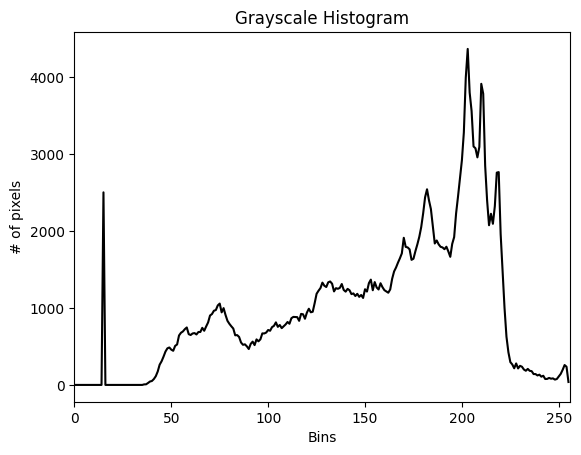

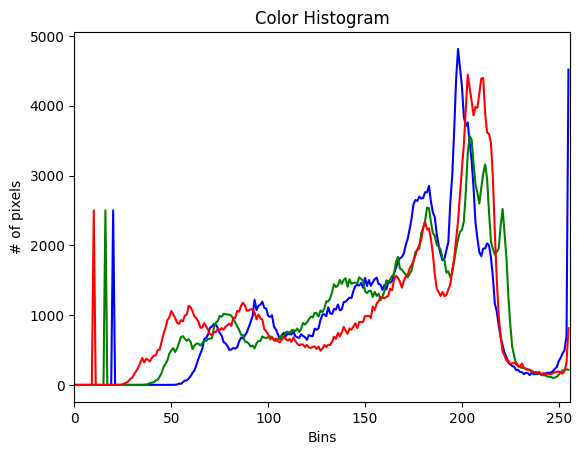

In [9]:
# computing histogram is used to visualize the color of the pixel intensity distribution

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt  # for displaying histograms

# Read image
img = cv.imread(r"C:\Users\akhil\OneDrive\Pictures\Screenshots\Screenshot 2025-12-07 192924.png")
cv.imshow('Original Image', img)

# Resize image
resized = cv.resize(img, (500, 500))
cv.imshow('Resized', resized)

# ---------------------------
# MASK CREATION
# ---------------------------
blank = np.zeros(resized.shape[:2], dtype='uint8')

# Circle mask
circle = cv.circle(blank.copy(), (resized.shape[1]//2, resized.shape[0]//2), 100, 255, -1)

# Rectangle mask
rectangle = cv.rectangle(blank.copy(), (30, 30), (370, 370), 255, -1)

# Combine circle + rectangle (intersection)
weird_shape = cv.bitwise_and(circle, rectangle)
cv.imshow('Weird Shape Mask', weird_shape)

# Apply mask to image
masked = cv.bitwise_and(resized, resized, mask=weird_shape)
cv.imshow('Masked Image', masked)

# ---------------------------
# GRAYSCALE HISTOGRAM
# ---------------------------
gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
cv.imshow('Gray', gray)

gray_hist = cv.calcHist([gray], [0], None, [256], [0, 256])  # cv.calcHist(images, channels, mask, histSize, ranges)
plt.figure()
plt.title('Grayscale Histogram')
plt.xlabel('Bins')
plt.ylabel('# of pixels')
plt.plot(gray_hist, color='black')
plt.xlim([0, 256])  # plt.xlim([min, max])
plt.show()

# ---------------------------
# COLOR HISTOGRAM (B, G, R)
# ---------------------------
plt.figure()
plt.title('Color Histogram')
plt.xlabel('Bins')
plt.ylabel('# of pixels')

colors = ('b', 'g', 'r')
for i, col in enumerate(colors):
    hist = cv.calcHist([resized], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    plt.xlim([0, 256])

plt.show()

cv.waitKey(0)
cv.destroyAllWindows()


In [ ]:
#thresholding - binarization of an image
# in this we take an image and convert it to binary image
# 2-types : simple and adaptive thresholding
import cv2 as cv
import numpy as np


# Read image
img = cv.imread(r"C:\Users\akhil\OneDrive\Pictures\Screenshots\Screenshot 2025-12-07 192924.png")
cv.imshow('Original Image', img)


# Resize image
resized = cv.resize(img, (500, 500)) 
cv.imshow('Resized', resized)

gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY) 
cv.imshow('Gray', gray) 


# when we increse the threshold value(210) ,less parts of the image will be white and all black image completely
threshold,thresh=cv.threshold(gray,210,255,cv.THRESH_BINARY)
cv.imshow('simple Thresh',thresh)


#INVERSE THRESHOLD-in inverse threshold all the black parts of image is turned into white and white parts turned into black of threshol
threshold,thresh_inv=cv.threshold(gray,210,255,cv.THRESH_BINARY_INV)
cv.imshow('inverse Thresh',thresh_inv) 


#ADAPTIVE THRESHOLD (it is good) - it is like a sketch art , which draws the outline of te image 
adaptive_thresh=cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_MEAN_C,cv.THRESH_BINARY,5,3)
cv.imshow('adaptive Thresh',adaptive_thresh)


cv.waitKey(0)

In [ ]:
                            #gradients and edge detection
import cv2 as cv
import numpy as np

# Read image
img = cv.imread(r"C:\Users\akhil\OneDrive\Pictures\Screenshots\Screenshot 2025-12-07 192924.png")
cv.imshow('Original Image', img)


# Resize image
resized = cv.resize(img, (500, 500))
cv.imshow('Resized', resized)

gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
cv.imshow('Gray', gray)


#laplacian is like pencil shading.  Highlights edges and fine details in all directions.
lap=cv.Laplacian(img,cv.CV_64F)
lap=np.uint8(np.absolute(lap))
cv.imshow('Laplacian',lap) 


#sobel - gradient magnitude representation. it computs the gradients in 2 directions
sobelx=cv.Sobel(gray,cv.CV_64F,1,0) # it highlights the details in vertical direction
sobely=cv.Sobel(gray,cv.CV_64F,0,1) # in horizontal direction
combined_sobel=cv.bitwise_or(sobelx,sobely)


cv.imshow('sobel x ',sobelx)
cv.imshow('sobel y ',sobely)
cv.imshow('comined_sobel',combined_sobel)


canny=cv.Canny(gray,150,175)
cv.imshow('cany',canny)

cv.waitKey(0)

In [1]:
# face recognition is different from the face detection
#face dectection is performed using the classifiers . classifier is an algorithm that detects whether the image is positive or negative    
#open cv has lot of pertrained classifiers . 
#mailny 2 classifiers : 1)har cascades , local core binary patterns
#face detection does not involve in the skin tone or colour

import cv2 as cv
import numpy as np

# Read image
img = cv.imread(r"C:\Users\akhil\OneDrive\Pictures\Screenshots\Screenshot 2025-12-07 192924.png")
cv.imshow('Original Image', img)

# Resize image
resized = cv.resize(img, (500, 500))
cv.imshow('Resized', resized)

# Convert to grayscale (important for Haar cascades)
gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
cv.imshow('Gray', gray)

# Load Haar cascade classifier
haar_cascade = cv.CascadeClassifier(r"C:\Users\akhil\Downloads\haarcascade_frontalface_default.xml")

# Detect faces
faces_rect = haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)
#scaleFactor=1.1 — how much the image size is reduced at each scale.
#minNeighbors=4 — higher → fewer detections but more accurate.


print(f'Number of faces found = {len(faces_rect)}')

# Draw rectangles around faces
for (x, y, w, h) in faces_rect:
    cv.rectangle(resized, (x, y), (x + w, y + h), (0, 255, 0), thickness=2)

cv.imshow('Detected Faces', resized)

cv.waitKey(0)
cv.destroyAllWindows()



error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\objdetect\src\cascadedetect.cpp:1689: error: (-215:Assertion failed) !empty() in function 'cv::CascadeClassifier::detectMultiScale'


In [ ]:
#face recognition 

import cv2 as cv
import numpy as np
# Read image
img = cv.imread(r"C:\Users\akhil\OneDrive\Pictures\festive pic.jpg")
cv.imshow('Original Image', img)

# Resize image
resized = cv.resize(img, (500, 500))
cv.imshow('Resized', resized)
gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
cv.imshow('Gray', gray)


In [ ]:
# training the model

import os
import cv2 as cv
import numpy as np

# Define people and directory
people = ['pics', 'gopi']
DIR = r"C:\Users\akhil\OneDrive\Pictures\faces"

# Load Haar Cascade
haar_cascade = cv.CascadeClassifier(r"C:\Users\akhil\Downloads\haarcascade_frontalface_default.xml")

# Lists for training data
features = []
labels = []

def create_train():
    for person in people:
        path = os.path.join(DIR, person)
        label = people.index(person)

        for img in os.listdir(path):
            img_path = os.path.join(path, img)
            img_array = cv.imread(img_path)

            if img_array is None:
                continue  # skip unreadable images

            gray = cv.cvtColor(img_array, cv.COLOR_BGR2GRAY)

            faces_rect = haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)

            for (x, y, w, h) in faces_rect:
                faces_roi = gray[y:y + h, x:x + w]
                features.append(faces_roi)
                labels.append(label)

# Run training data creation
create_train()

print('Training data creation complete!')
print(f'Length of features = {len(features)}')
print(f'Length of labels = {len(labels)}')

# Convert to numpy arrays
features = np.array(features, dtype='object')
labels = np.array(labels)

# Train recognizer
face_recognizer = cv.face.LBPHFaceRecognizer_create()
face_recognizer.train(features, labels)

# Save trained model and data
face_recognizer.save(r"C:\Users\akhil\Downloads\face_trained_model.yml")
np.save(r"C:\Users\akhil\Downloads\features.npy", features)
np.save(r"C:\Users\akhil\Downloads\labels.npy", labels)

print("Training completed and model saved successfully ✅")


In [ ]:
#using the trained model

import cv2 as cv
import numpy as np

# Load Haar cascade
haar_cascade = cv.CascadeClassifier(r"C:\Users\akhil\Downloads\haarcascade_frontalface_default.xml")

# People list (same order as during training)
people = ['akhila', 'sri']

# Load trained data
features = np.load(r"C:\Users\akhil\Downloads\features.npy", allow_pickle=True)
labels = np.load(r"C:\Users\akhil\Downloads\labels.npy")

# Load trained model
face_recognizer = cv.face.LBPHFaceRecognizer_create()
face_recognizer.read(r"C:\Users\akhil\Downloads\face_trained_model.yml")

# Read test image
img = cv.imread(r"C:\Users\akhil\OneDrive\Pictures\faces\gopi\hero.jpg")
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv.imshow('Gray', gray)

# Detect faces
faces_rect = haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=7)

for (x, y, w, h) in faces_rect:
    faces_roi = gray[y:y+h, x:x+w]

    # Predict the person
    label, confidence = face_recognizer.predict(faces_roi)
    print(f"Label = {people[label]} with a confidence of {confidence:.2f}")

    # Draw rectangle and text
    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), thickness=2)
    cv.putText(img, str(people[label]), (x, y - 10), cv.FONT_HERSHEY_COMPLEX, 1.0, (0, 255, 0), thickness=2)

cv.imshow('Detected Face', img)
cv.waitKey(0)
cv.destroyAllWindows()



## MediaPipe